# Titanic Survival — Sandbox Notebook

**Purpose:** This is the data scientist's *lab bench* — an interactive space to explore data, inspect intermediate pipeline states, and debug module logic.

**Ground rules:**
- This notebook runs **entirely in memory** and writes **no production artifacts** to disk.
- The only authorised entry point for writing `data/processed/clean.csv`, `models/model.joblib`, and `reports/predictions.csv` is `python -m src.main`.
- Keep `PROTECT_TEST_SET = True` while experimenting. Only flip it to `False` when you are ready for a final, one-shot evaluation.

---

In [9]:
import sys
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install scikit-learn

In [10]:
# --- Robust repo root discovery so `import src...` works everywhere ---
import os
import sys
from pathlib import Path

def find_repo_root(start=None):
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / "src").is_dir() and ((p / "config.yaml").exists() or (p / ".git").exists()):
            return p
    return start

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repo root :", REPO_ROOT)
print("Working dir:", Path.cwd())

Repo root : /Users/isso/Downloads/MLOPS/1-mlops-kickoff-repo
Working dir: /Users/isso/Downloads/MLOPS/1-mlops-kickoff-repo


## Settings

All configuration is defined here in one place. `FEATURE_COLS` must match the columns produced by `clean_dataframe()` — note that `FamilySize` and `Title` are **engineered** features that do not exist in the raw CSV; they are created during cleaning.

In [11]:
TARGET       = "Survived"
PROBLEM_TYPE = "classification"
RANDOM_STATE = 42
RAW_DATA_PATH = Path("data/raw/titanic.csv")

# Feature groups — must match the columns produced by clean_dataframe()
NUMERIC_COLS      = ["Age", "Fare", "FamilySize"]          # -> StandardScaler
CATEGORICAL_COLS  = ["Pclass", "Sex", "Embarked", "Title"] # -> OneHotEncoder
QUANTILE_BIN_COLS = []                                      # optional; unused in baseline

FEATURE_COLS  = NUMERIC_COLS + CATEGORICAL_COLS
REQUIRED_COLS = FEATURE_COLS + [TARGET]

TEST_SIZE = 0.15
VAL_SIZE  = 0.15  # fraction of the full dataset, carved from the non-test remainder

# Flip to False only for a final, one-shot test-set evaluation
PROTECT_TEST_SET = True

print("Settings OK.")
print(f"  Numeric features   : {NUMERIC_COLS}")
print(f"  Categorical features: {CATEGORICAL_COLS}")
print(f"  Target             : {TARGET}")

Settings OK.
  Numeric features   : ['Age', 'Fare', 'FamilySize']
  Categorical features: ['Pclass', 'Sex', 'Embarked', 'Title']
  Target             : Survived


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report

from src.load_data import load_data
from src.clean_data import clean_data
from src.validate import validate_dataframe
from src.features import get_feature_preprocessor
from src.train import train_model
from src.evaluate import evaluate_model
from src.infer import run_inference

print("Imports OK.")

Imports OK.


## 1 — Load Raw Data

In [13]:
df_raw = load_data(RAW_DATA_PATH)
df_raw_snapshot = df_raw.copy(deep=True)  # immutable reference for later comparisons

print(f"Raw data shape: {df_raw.shape}")
df_raw.head(3)

2026-03-09 21:31:01,447 | INFO | Loaded raw data: path=data/raw/titanic.csv shape=(891, 12)


[utils.setup_logger] Setting up logger: file=reports/run.log level=INFO
Raw data shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 2 — Exploratory Data Analysis

This section surfaces the key data quality and distribution facts that drive cleaning and feature engineering decisions downstream.

In [14]:
# ── Schema and missing values ─────────────────────────────────────────────
print("── dtypes ──")
display(df_raw.dtypes)

print("\n── Missing value rate (sorted) ──")
display(
    df_raw.isna().mean()
    .sort_values(ascending=False)
    .head(15)
    .rename("missing_rate")
)

print(f"\nShape                           : {df_raw.shape}")
print(f"Duplicate rows                  : {df_raw.duplicated().sum()}")
print(f"Target prevalence (Survived=1)  : {df_raw[TARGET].mean():.1%}")

── dtypes ──


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


── Missing value rate (sorted) ──


Cabin          0.771044
Age            0.198653
Embarked       0.002245
PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Name: missing_rate, dtype: float64


Shape                           : (891, 12)
Duplicate rows                  : 0
Target prevalence (Survived=1)  : 38.4%


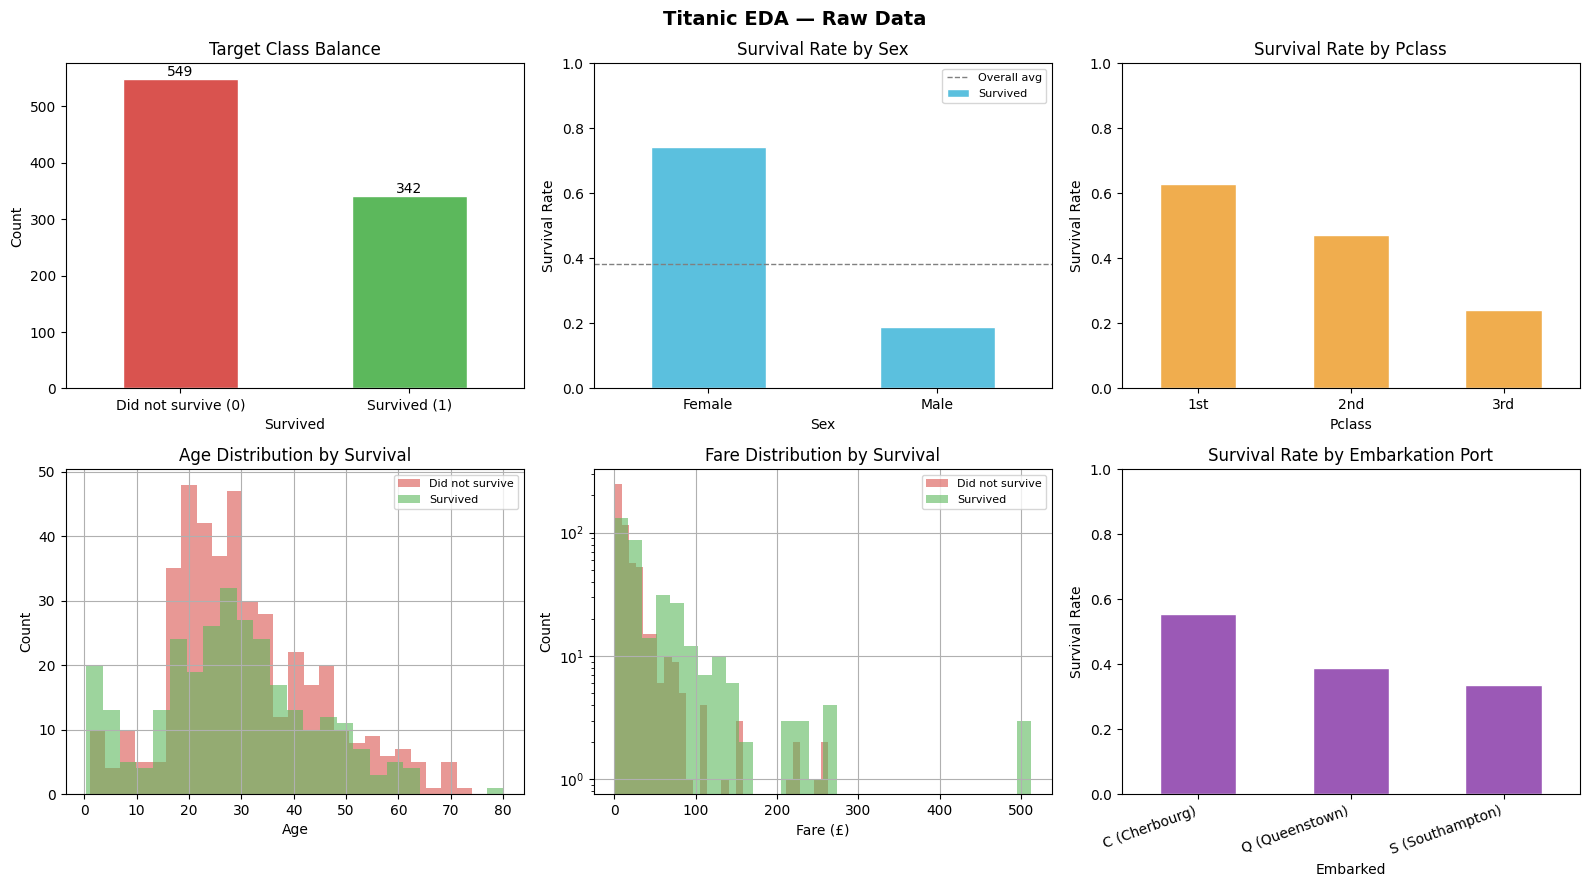

In [15]:
# ── EDA visualisations ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Titanic EDA — Raw Data", fontsize=14, fontweight="bold")

# 1. Target class balance
ax = axes[0, 0]
df_raw[TARGET].value_counts().sort_index().plot(
    kind="bar", ax=ax, color=["#d9534f", "#5cb85c"], edgecolor="white"
)
ax.set_title("Target Class Balance")
ax.set_xlabel("Survived")
ax.set_ylabel("Count")
ax.set_xticklabels(["Did not survive (0)", "Survived (1)"], rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height() + 5),
                ha="center", fontsize=10)

# 2. Survival rate by Sex
ax = axes[0, 1]
df_raw.groupby("Sex")[TARGET].mean().plot(
    kind="bar", ax=ax, color="#5bc0de", edgecolor="white"
)
ax.set_title("Survival Rate by Sex")
ax.set_ylabel("Survival Rate")
ax.set_xticklabels(["Female", "Male"], rotation=0)
ax.set_ylim(0, 1)
ax.axhline(df_raw[TARGET].mean(), color="grey", linestyle="--",
           linewidth=1, label="Overall avg")
ax.legend(fontsize=8)

# 3. Survival rate by Pclass
ax = axes[0, 2]
df_raw.groupby("Pclass")[TARGET].mean().plot(
    kind="bar", ax=ax, color="#f0ad4e", edgecolor="white"
)
ax.set_title("Survival Rate by Pclass")
ax.set_ylabel("Survival Rate")
ax.set_xticklabels(["1st", "2nd", "3rd"], rotation=0)
ax.set_ylim(0, 1)

# 4. Age distribution by survival
ax = axes[1, 0]
df_raw[df_raw[TARGET] == 0]["Age"].dropna().hist(
    ax=ax, bins=25, alpha=0.6, color="#d9534f", label="Did not survive"
)
df_raw[df_raw[TARGET] == 1]["Age"].dropna().hist(
    ax=ax, bins=25, alpha=0.6, color="#5cb85c", label="Survived"
)
ax.set_title("Age Distribution by Survival")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

# 5. Fare distribution by survival (log scale)
ax = axes[1, 1]
df_raw[df_raw[TARGET] == 0]["Fare"].dropna().hist(
    ax=ax, bins=30, alpha=0.6, color="#d9534f", label="Did not survive"
)
df_raw[df_raw[TARGET] == 1]["Fare"].dropna().hist(
    ax=ax, bins=30, alpha=0.6, color="#5cb85c", label="Survived"
)
ax.set_title("Fare Distribution by Survival")
ax.set_xlabel("Fare (£)")
ax.set_ylabel("Count")
ax.set_yscale("log")
ax.legend(fontsize=8)

# 6. Survival rate by Embarked
ax = axes[1, 2]
df_raw.groupby("Embarked")[TARGET].mean().sort_values(ascending=False).plot(
    kind="bar", ax=ax, color="#9b59b6", edgecolor="white"
)
ax.set_title("Survival Rate by Embarkation Port")
ax.set_ylabel("Survival Rate")
ax.set_xticklabels(
    ["C (Cherbourg)", "Q (Queenstown)", "S (Southampton)"],
    rotation=20, ha="right"
)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 3 — Clean Data

After calling `clean_data()` we verify that:
1. All missing values have been imputed (Age, Fare, Embarked).
2. The two engineered features `FamilySize` and `Title` are present with sensible distributions.

In [16]:
from src.utils import read_config

config = read_config("config.yaml")
df_clean = clean_data(df_raw, config)

# Engineer features expected by the model (FamilySize, Title)
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1

df_clean["Title"] = df_clean["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
rare_titles = df_clean["Title"].value_counts()
rare_titles = rare_titles[rare_titles < 10].index
df_clean["Title"] = df_clean["Title"].replace(rare_titles, "Rare")

print(f"Shape before cleaning : {df_raw_snapshot.shape}")
print(f"Shape after  cleaning : {df_clean.shape}")
df_clean.head(3)


2026-03-09 21:31:01,702 | INFO | Cleaned data: start_rows=891 end_rows=891 dropped=0


[utils.read_config] Reading config from: config.yaml
[utils.setup_logger] Setting up logger: file=reports/pipeline.log level=INFO
Shape before cleaning : (891, 12)
Shape after  cleaning : (891, 14)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Miss


In [17]:
# ── Post-cleaning verification ────────────────────────────────────────────
print("── Remaining nulls after cleaning ──")
null_counts = df_clean.isna().sum()
if null_counts.sum() == 0:
    print("  None — all columns fully imputed.")
else:
    print(null_counts[null_counts > 0])

print("\n── Engineered feature: FamilySize (value counts) ──")
assert "FamilySize" in df_clean.columns, "ERROR: FamilySize missing after cleaning!"
print(df_clean["FamilySize"].value_counts().sort_index())

print("\n── Engineered feature: Title (value counts) ──")
assert "Title" in df_clean.columns, "ERROR: Title missing after cleaning!"
print(df_clean["Title"].value_counts())

print("\n── Final columns ──")
print(list(df_clean.columns))

── Remaining nulls after cleaning ──
Cabin    687
dtype: int64

── Engineered feature: FamilySize (value counts) ──
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

── Engineered feature: Title (value counts) ──
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

── Final columns ──
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'Title']


## 4 — Validate

`validate_dataframe()` is a **fail-fast gate**. If it raises a `ValueError` here, stop and fix the cleaning step — do not attempt to train on invalid data.

In [18]:
validate_dataframe(df_clean, required_columns=REQUIRED_COLS)
print("Validation passed — data is safe to split and train on.")

[validate.validate_dataframe] Validating dataframe
[validate.validate_dataframe] Validation successful
Validation passed — data is safe to split and train on.


## 5 — Train / Val / Test Split

**Leakage prevention:** the split happens here, *before* the feature preprocessor is built or fitted. The `ColumnTransformer` will only ever see `X_train` during `.fit()`. The val and test sets are transformed later using statistics computed exclusively from training data.

In [19]:
X = df_clean[FEATURE_COLS].copy()
y = df_clean[TARGET].copy()

# Step 1: carve out the held-out test set
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Step 2: split the remainder into train and val
val_fraction_of_remaining = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp,
    test_size=val_fraction_of_remaining,
    random_state=RANDOM_STATE,
    stratify=y_tmp,
)

print(f"Train : {X_train.shape}  |  survival rate: {y_train.mean():.1%}")
print(f"Val   : {X_val.shape}   |  survival rate: {y_val.mean():.1%}")
print(f"Test  : {X_test.shape}  |  survival rate: {y_test.mean():.1%}")
print("\nStratified split confirmed — class proportions are consistent across all splits.")

Train : (623, 7)  |  survival rate: 38.4%
Val   : (134, 7)   |  survival rate: 38.8%
Test  : (134, 7)  |  survival rate: 38.1%

Stratified split confirmed — class proportions are consistent across all splits.


## 6 — Build Feature Preprocessor

`get_feature_preprocessor()` returns an **unfitted** `ColumnTransformer`. Nothing is learned from data in this cell. Fitting happens inside `train_model()` wrapped in a sklearn `Pipeline`, ensuring no information from val or test sets leaks into the preprocessing step.

In [20]:
preprocessor = get_feature_preprocessor(
    quantile_bin_cols=QUANTILE_BIN_COLS,
    categorical_onehot_cols=CATEGORICAL_COLS,
    numeric_passthrough_cols=NUMERIC_COLS,
    n_bins=3,
)

preprocessor  # displays the unfitted sklearn diagram

[features.get_feature_preprocessor] Building ColumnTransformer feature recipe
[features.get_feature_preprocessor] quantile_bin_cols=[], categorical_onehot_cols=['Pclass', 'Sex', 'Embarked', 'Title'], numeric_passthrough_cols=['Age', 'Fare', 'FamilySize'], remainder=drop


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_onehot', ...), ('numeric_passthrough', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name

## 7 — Train Model

In [23]:
train_config = {
    "model_name": "logistic_regression",
    "random_state": RANDOM_STATE,
    "model_output_path": "models/model.joblib",
}

model = train_model(
    X_train=X_train,
    y_train=y_train,
    preprocessor=preprocessor,
    config=train_config,
)

model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_onehot', ...), ('numeric_passthrough', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

## 8 — Evaluate on Validation Set

`evaluate_model()` returns a single scalar metric (weighted F1) and prints the full classification report to the console. The cells below render the confusion matrix and ROC curve visually for deeper diagnostic inspection.

In [25]:
eval_config = {"problem_type": PROBLEM_TYPE, "primary_metric": "f1", "save_reports": False}
metrics = evaluate_model(model, X_val, y_val, config=eval_config)
val_f1 = metrics["f1"]
print(f"\nValidation weighted F1: {val_f1:.4f}")



Validation weighted F1: 0.8257


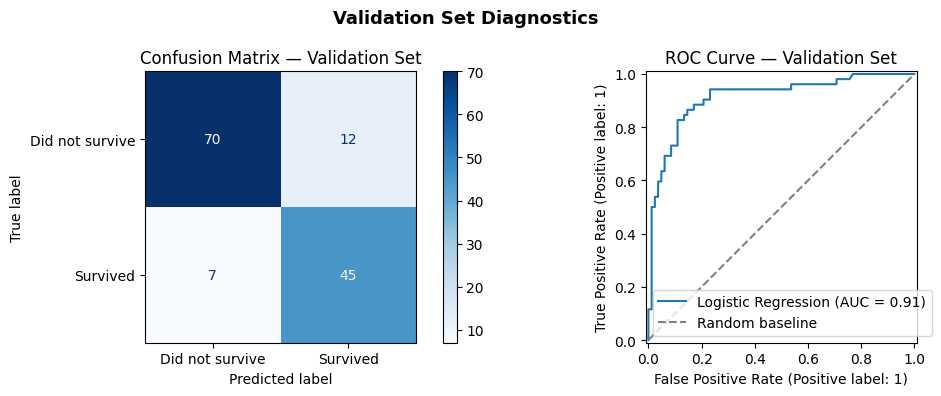


── Full Classification Report ──
                 precision    recall  f1-score   support

Did not survive       0.91      0.85      0.88        82
       Survived       0.79      0.87      0.83        52

       accuracy                           0.86       134
      macro avg       0.85      0.86      0.85       134
   weighted avg       0.86      0.86      0.86       134



In [26]:
# ── Visual diagnostics ───────────────────────────────────────────────────
y_val_pred  = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Validation Set Diagnostics", fontsize=13, fontweight="bold")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred,
    display_labels=["Did not survive", "Survived"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix — Validation Set")

# ROC curve
RocCurveDisplay.from_predictions(
    y_val, y_val_proba,
    name="Logistic Regression",
    ax=axes[1],
)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random baseline")
axes[1].set_title("ROC Curve — Validation Set")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n── Full Classification Report ──")
print(classification_report(
    y_val, y_val_pred,
    target_names=["Did not survive", "Survived"]
))

## 9 — Final Evaluation on Test Set (Guarded)

> ⚠️ **Why the guard exists:** The test set is your single, unbiased estimate of real-world performance. Every time you examine test metrics and then adjust your model, you are implicitly overfitting to the test set — even if you do not retrain on it directly. For that reason `PROTECT_TEST_SET = True` by default. Only flip it to `False` when you have made your **final** modelling decision and need one conclusive number to report.

In [27]:
if not PROTECT_TEST_SET:
    print("── FINAL TEST SET EVALUATION ──")
    test_f1 = evaluate_model(model, X_test, y_test, problem_type=PROBLEM_TYPE)
    print(f"\nTest weighted F1: {test_f1:.4f}")
else:
    print("Test set is protected.")
    print("Set PROTECT_TEST_SET = False in the Settings cell to run the final evaluation.")

Test set is protected.
Set PROTECT_TEST_SET = False in the Settings cell to run the final evaluation.


## 10 — Inference

`run_inference()` returns a **four-column** DataFrame: `prediction`, `survival_probability`, `outcome`, and `high_confidence`. We use the first 10 rows of the validation set as a stand-in for genuinely unseen passengers.

In [28]:
# Simulate new, unseen passengers using the first 10 rows of the validation set
X_infer = X_val.head(10).copy()

preds = run_inference(model, X_infer)

print("\n── Enriched Predictions (all 4 contract columns) ──")
display(preds)

print(f"\nPredicted survival rate    : {preds['prediction'].mean():.1%}")
print(f"Mean survival probability  : {preds['survival_probability'].mean():.3f}")
print(f"High-confidence predictions: {preds['high_confidence'].sum()} / {len(preds)}")

[infer] Running inference on 10 records...
[infer] Inference complete. Predictions shape: (10, 1)
[infer] Survival rate in predictions: 30.00%
[infer] Mean survival probability: 37.12%
[infer] High-confidence predictions: 80.00%

── Enriched Predictions (all 4 contract columns) ──


,prediction,survival_probability,outcome,high_confidence
675,0,0.113449,Did not survive,True
561,0,0.061481,Did not survive,True
83,0,0.463688,Did not survive,False
708,1,0.958849,Survived,True
568,0,0.124168,Did not survive,True
37,0,0.104693,Did not survive,True
648,0,0.093621,Did not survive,True
125,1,0.584993,Survived,False
290,1,0.937199,Survived,True
757,0,0.269956,Did not survive,True



Predicted survival rate    : 30.0%
Mean survival probability  : 0.371
High-confidence predictions: 8 / 10


Borderline predictions (low confidence): 2 row(s)


,prediction,survival_probability,outcome,high_confidence
83,0,0.463688,Did not survive,False
125,1,0.584993,Survived,False


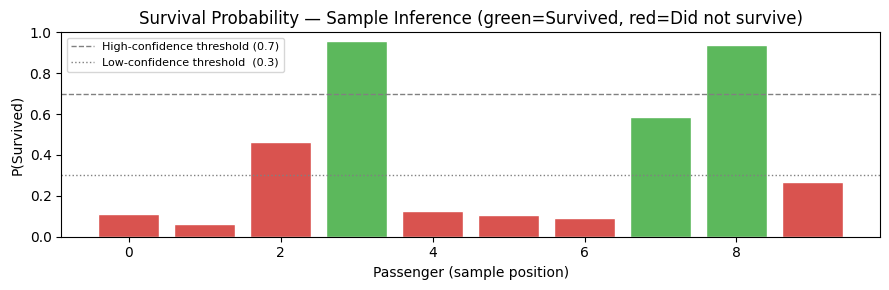


Accuracy on these 10 rows: 100%


,prediction,actual,survival_probability,outcome,high_confidence,correct
675,0,0,0.113449,Did not survive,True,True
561,0,0,0.061481,Did not survive,True,True
83,0,0,0.463688,Did not survive,False,True
708,1,1,0.958849,Survived,True,True
568,0,0,0.124168,Did not survive,True,True
37,0,0,0.104693,Did not survive,True,True
648,0,0,0.093621,Did not survive,True,True
125,1,1,0.584993,Survived,False,True
290,1,1,0.937199,Survived,True,True
757,0,0,0.269956,Did not survive,True,True


In [29]:
# ── Explore the enriched output ───────────────────────────────────────────

# Borderline passengers — model is uncertain (probability between 0.3 and 0.7)
borderline = preds[~preds["high_confidence"]]
print(f"Borderline predictions (low confidence): {len(borderline)} row(s)")
if len(borderline) > 0:
    display(borderline)

# Probability bar chart
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(
    range(len(preds)),
    preds["survival_probability"],
    color=["#5cb85c" if p == 1 else "#d9534f" for p in preds["prediction"]],
    edgecolor="white",
)
ax.axhline(0.7, color="grey", linestyle="--", linewidth=1, label="High-confidence threshold (0.7)")
ax.axhline(0.3, color="grey", linestyle=":",  linewidth=1, label="Low-confidence threshold  (0.3)")
ax.set_title("Survival Probability — Sample Inference (green=Survived, red=Did not survive)")
ax.set_xlabel("Passenger (sample position)")
ax.set_ylabel("P(Survived)")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Cross-reference against actual labels
preds_vs_actual = preds.copy()
preds_vs_actual["actual"] = y_val.head(10).values
preds_vs_actual["correct"] = preds_vs_actual["prediction"] == preds_vs_actual["actual"]
print(f"\nAccuracy on these 10 rows: {preds_vs_actual['correct'].mean():.0%}")
display(
    preds_vs_actual[[
        "prediction", "actual", "survival_probability",
        "outcome", "high_confidence", "correct"
    ]]
)

## 11 — Run the Orchestrator

The cells above run the pipeline **in memory** and write nothing to disk. To produce the canonical production artifacts, run from your terminal:

```bash
python -m src.main
```

The cell below invokes the orchestrator via `subprocess` as a smoke test. It prints stdout/stderr and explains common failure causes rather than raising a bare `RuntimeError`.

In [31]:
import subprocess

cmd = [sys.executable, "-m", "src.main"]
print("Running:", " ".join(cmd))

r = subprocess.run(cmd, cwd=str(REPO_ROOT), capture_output=True, text=True)

print("---- STDOUT ----")
print(r.stdout)
print("---- STDERR ----")
print(r.stderr)

if r.returncode != 0:
    print(f"\n--- Orchestrator exited with code {r.returncode} ---")
    print("Common causes:")
    print("  1. SETTINGS['raw_data_path'] in main.py points to a file that does not exist.")
    print("  2. SETTINGS['is_example_config'] is True but the expected dummy CSV is missing.")
    print("  3. A bug was introduced in one of the student code sections.")
    print("\nFix the issue and re-run this cell.")
else:
    print("\nOrchestrator completed successfully. Artifacts written to disk.")

Running: /Users/isso/miniconda3/bin/python -m src.main
---- STDOUT ----
[utils.read_config] Reading config from: config.yaml
[main.main] Starting end-to-end pipeline.
[main.main] Ensuring artifact directories exist.
[utils.setup_logger] Setting up logger: file=reports/run.log level=INFO
[utils.setup_logger] Setting up logger: file=reports/run.log level=INFO
[utils.save_csv] Saving CSV to: data/processed/titanic_clean.csv
[validate.validate_dataframe] Validating dataframe
[validate.validate_dataframe] Validation successful
[main.main] Creating train-test split (before feature fitting).
[main.main] Running fail-fast feature configuration checks.
[main.main] Building preprocessing recipe.
[features.get_feature_preprocessor] Building ColumnTransformer feature recipe
[features.get_feature_preprocessor] quantile_bin_cols=[], categorical_onehot_cols=['Sex', 'Embarked'], numeric_passthrough_cols=['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], remainder=drop
[utils.save_model] Saving model to: mod